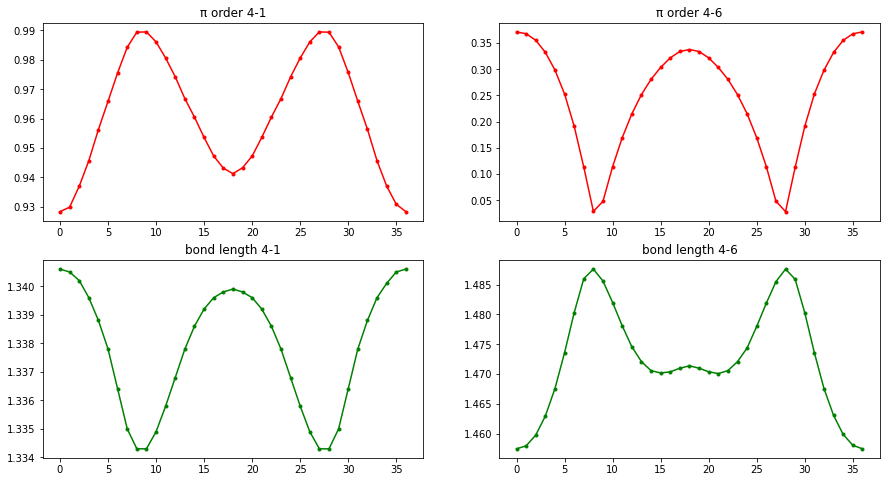

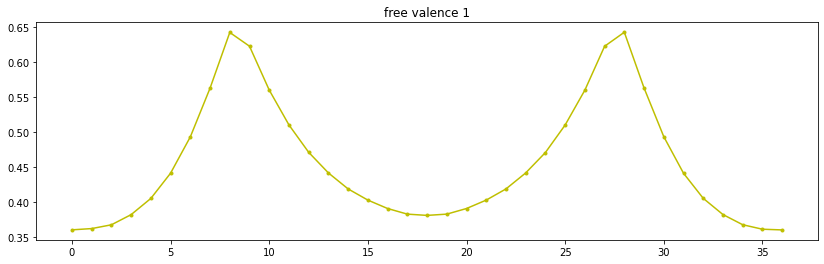

In [2]:
# 联苯键级键角图
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
def get_wfnOrders(atom1,atom2):
    with open(r"C:\code\HFV\files\scan\multiwfnRes.txt",'r',encoding='utf-8') as f:
        data=f.read()
    wfnOrders=re.findall(r'# +\d: +'+f'{atom1}'+'\(C \)    '+f'{atom2}'+'\(C \) +(\d.\d{8})',data)
    wfnOrders=np.array(wfnOrders,dtype=np.float32)
    return wfnOrders
def get_bondOrders(atom1,atom2):
    with open(r"C:\code\HFV\files\scan\RES9.txt",'r',encoding='utf-8') as f:
        data=f.read()
    datas=data.split('----------------------------------------------------------------------')[1:]
    all_res=[]
    all_valence=[]
    for each in datas:
        res=re.search(f'{atom1}->{atom2}'+r',bond order:(-?\d.\d{4}),bond length:(-?\d.\d{4})',each)
        valence=re.search(r'free valence:(-?\d.\d{4})',each).groups()
        if res is not None:
            all_res.append(res.groups())
        else:
            all_res.append([0,0])
        all_valence.append(valence)
    bondOrders=pd.DataFrame(all_res,dtype=float).to_numpy()[:,0]
    bondLengths=pd.DataFrame(all_res,dtype=float).to_numpy()[:,1]
    atomValence=pd.DataFrame(all_valence,dtype=float).to_numpy().flatten()
    return bondOrders,bondLengths,atomValence
fig,a=plt.subplots(2,2,figsize=(15, 8))
center=4
arounds=[1,6]
for i,around in enumerate(arounds):
    bondOrders,bondLengths,atomValence=get_bondOrders(center,around)
    a[0][i].set_title(f'π order {center}-{around}')
    a[0][i].plot(np.arange(len(bondOrders)),bondOrders,'r.-')
    a[1][i].set_title(f'bond length {center}-{around}')
    a[1][i].plot(np.arange(len(bondLengths)),bondLengths,'g.-')
fig,a=plt.subplots(figsize=(14, 4))
a.set_title('free valence 1')
a.plot(np.arange(len(atomValence)),atomValence,'y.-')
# 二面角增加，健级π键减小
# π健级=

In [17]:
import numpy as np
f=lambda a,x:2*(2*a/np.pi)**(3/4)*a**0.5*x*np.exp(-a*x**2)
x=np.arange(-5,5,0.1)

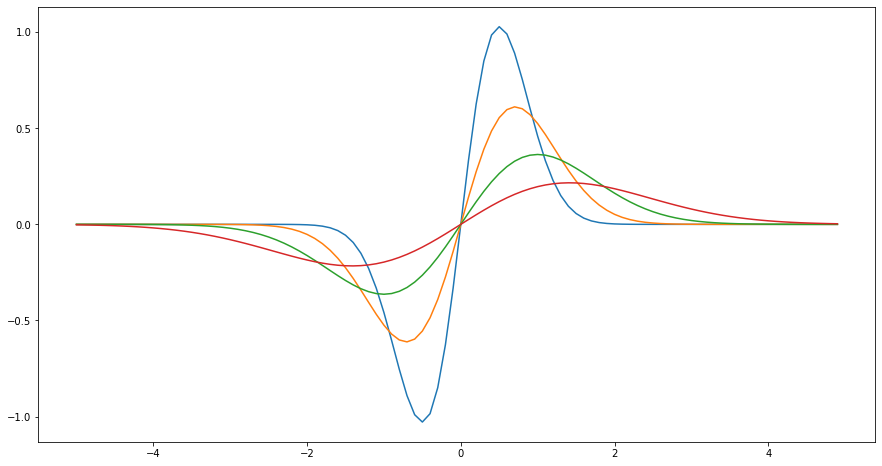

In [19]:
fig,a=plt.subplots(figsize=(15, 8))
a.plot(x,f(2,x))
a.plot(x,f(1,x))
a.plot(x,f(0.5,x))
a.plot(x,f(0.25,x))

In [ ]:
np.array([
[0.7868272350e+01 ,-0.1193324198e+00 , 0.6899906659e-01],
[0.1881288540e+01 ,-0.1608541517e+00 , 0.3164239610e+00],
[0.5442492580e+00 , 0.1143456438e+01 , 0.7443082909e+00],
[0.1687144782e+00 , 0.1000000000e+01 , 0.1000000000e+01]])
alphas=
px2,py2,pz2,px3,py3,pz3=[0.22351, -0.03345, 0.0, 0.0634, -0.02228, 0.0]
x=px2*1+px3*1